***1. Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

***2. Load Dataset***

In [2]:
df = pd.read_csv("/content/HeartDiseaseTrain-Test.csv")  # Kaggle UCI version
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


***3. Basic Data Inspection***

In [3]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


***4. Handle Missing Values***

In [4]:
df = df.dropna()   # safe baseline approach

***5. Exploratory Data Analysis (EDA)***

***Target distribution***

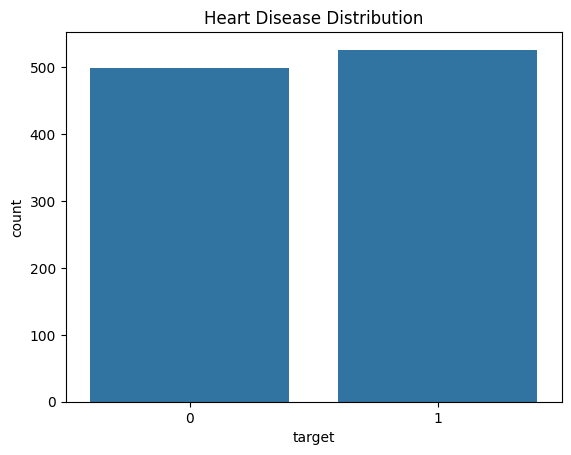

In [6]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

***Correlation heatmap***

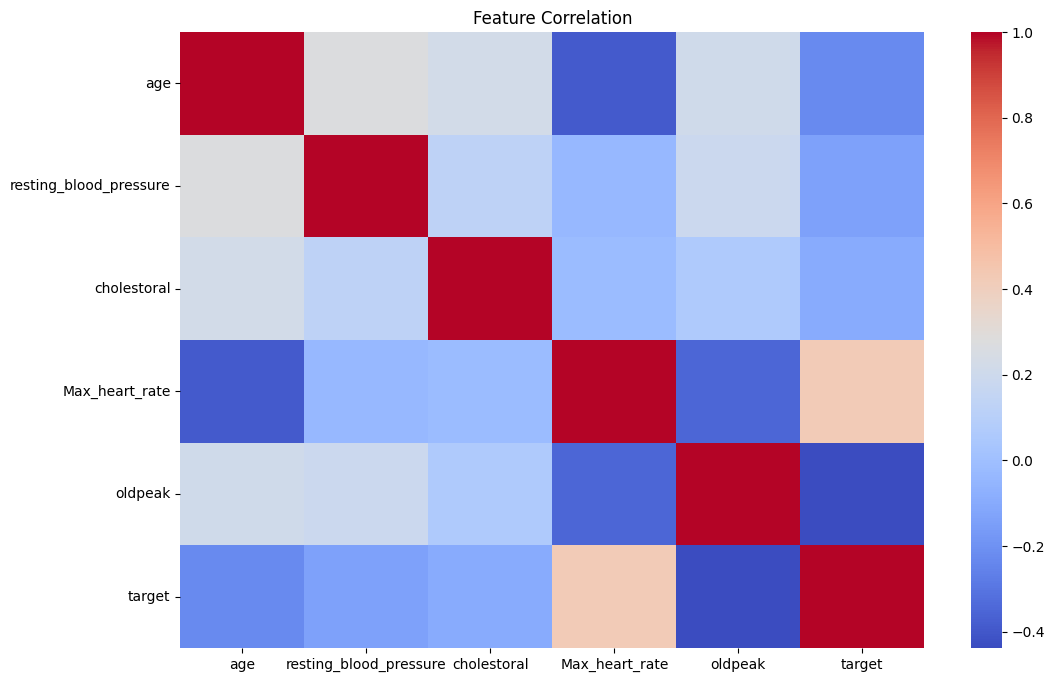

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [11]:
df.select_dtypes(include='object').columns

Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy',
       'thalassemia'],
      dtype='object')

In [13]:
df_encoded.dtypes

,0
age,int64
resting_blood_pressure,int64
cholestoral,int64
Max_heart_rate,int64
oldpeak,float64
target,int64
sex_Male,bool
chest_pain_type_Atypical angina,bool
chest_pain_type_Non-anginal pain,bool
chest_pain_type_Typical angina,bool


***Correlation***

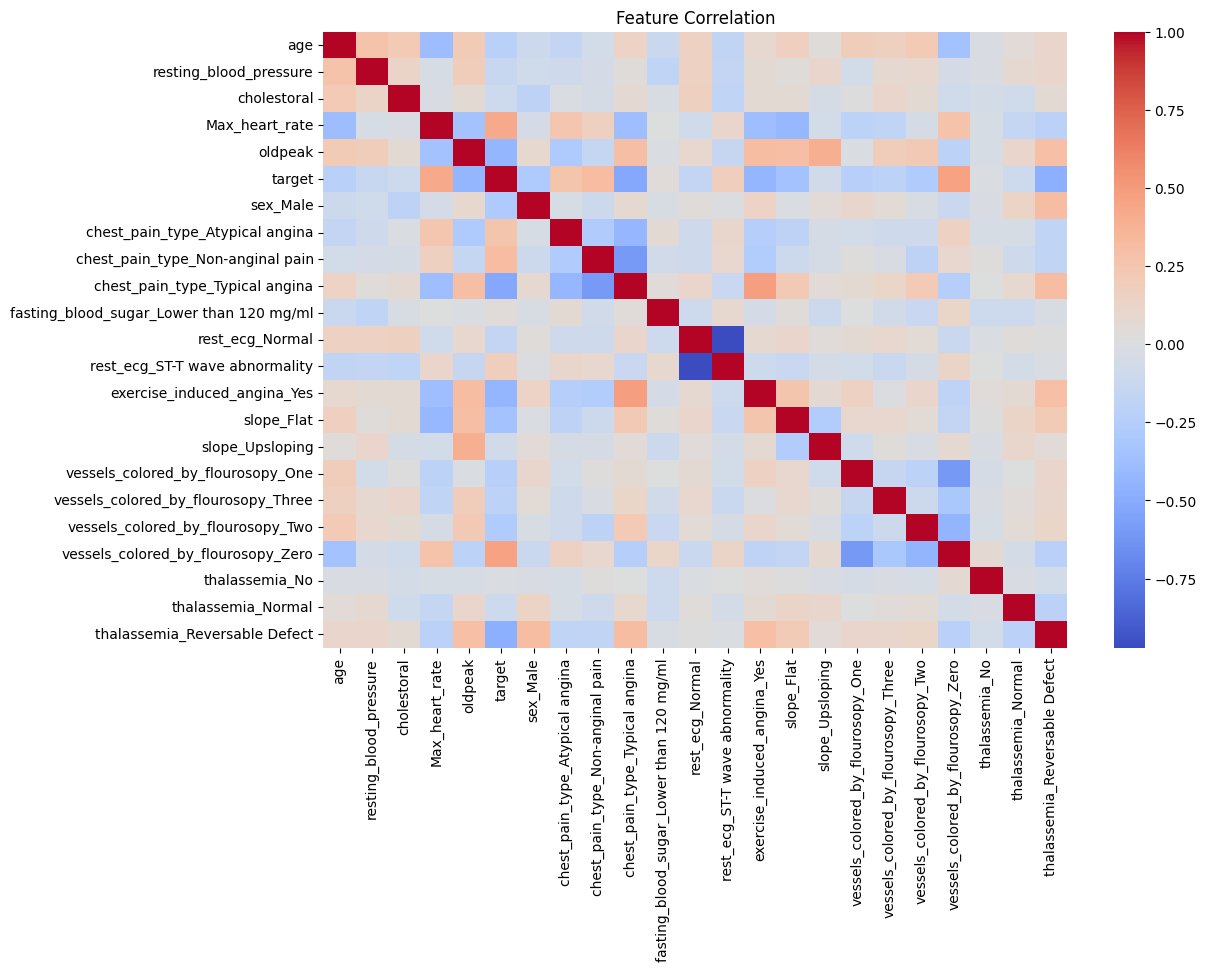

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# ***Heart Disease Classification Model***

In [16]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

***3. Feature Scaling (ONLY for Logistic Regression)***

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ***4. Train Models***
✔ Logistic Regression (baseline strong model)

In [19]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

***Decision Tree (interpretable model)***

In [20]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

***5. Predictions***

In [21]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_tree = tree_model.predict(X_test)

***6. Evaluation Metrics***

***Accuracy***

In [22]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Logistic Regression Accuracy: 0.8731707317073171
Decision Tree Accuracy: 0.8878048780487805


***Confusion Matrix (Logistic Regression)***

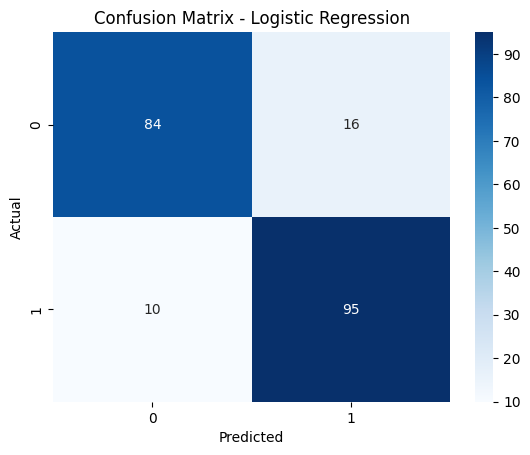

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

***ROC Curve + AUC (Logistic Regression)***

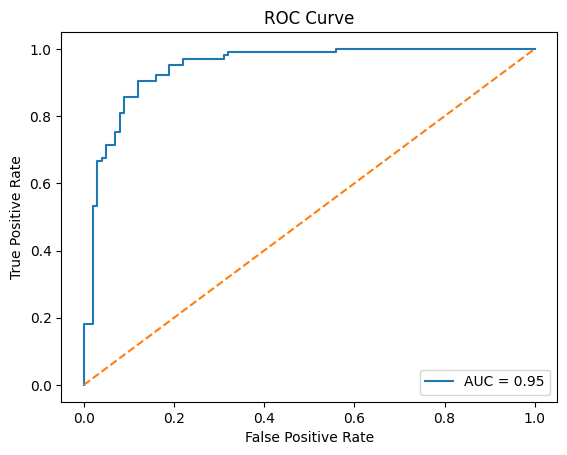

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

***7. Feature Importance***

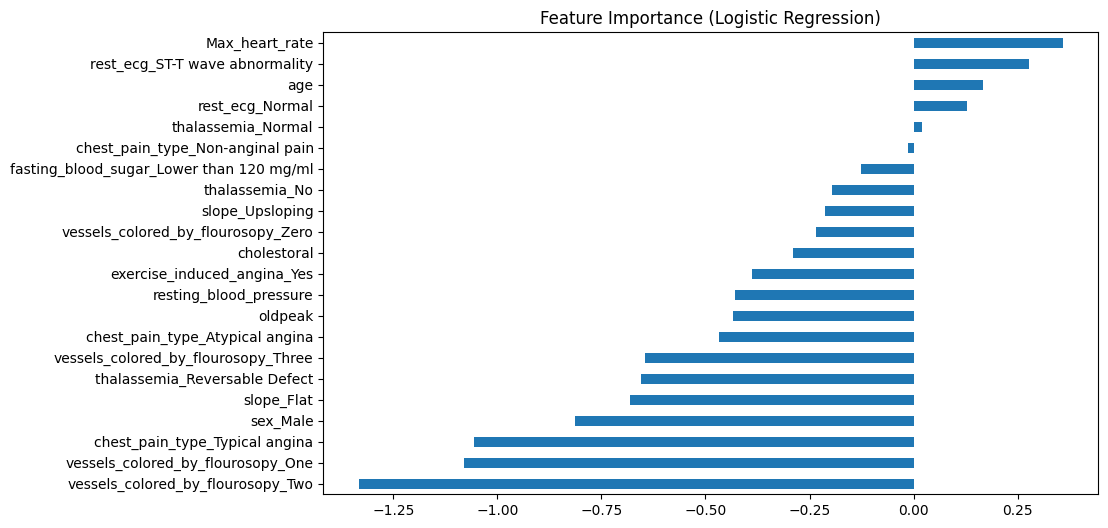

In [25]:
import pandas as pd

importance = pd.Series(
    log_model.coef_[0],
    index=X.columns
)

importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Logistic Regression)")
plt.show()

***Decision Tree Importance***

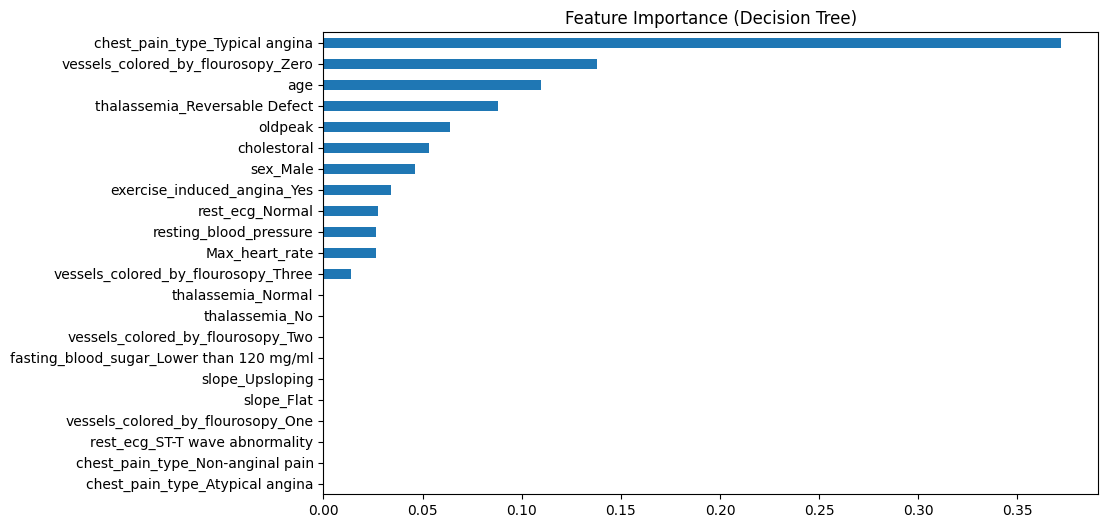

In [26]:
tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
)

tree_importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Decision Tree)")
plt.show()

# ***Heart Disease Prediction – Project Description***

This project focuses on building a machine learning model to predict whether a person is at risk of heart disease based on medical and clinical features. The dataset used is the Heart Disease UCI dataset, which contains patient health records such as chest pain type, blood pressure-related indicators, ECG results, and other diagnostic attributes.

***📌 1. Data Preparation & Cleaning***

The dataset was first inspected to understand its structure, feature types, and data quality. Categorical features such as chest pain type, thalassemia, and rest ECG were identified. These non-numeric values were converted into numerical format using one-hot encoding (pd.get_dummies) to make the data suitable for machine learning models. This step ensured that no string-based values remained in the dataset.

***📊 2. Exploratory Data Analysis (EDA)***

Exploratory analysis was performed to understand patterns and relationships between variables. Key techniques included:

Distribution analysis of target variable (heart disease presence)
Correlation heatmap to observe feature relationships
Understanding how medical attributes relate to disease outcome

This helped in identifying which features might influence heart disease prediction.

***⚙️ 3. Feature Engineering & Data Splitting***

The dataset was divided into input features (X) and target variable (y). After preprocessing, the data was split into training and testing sets using a stratified approach to ensure balanced class distribution. Feature scaling was applied for Logistic Regression to normalize numerical values and improve model performance.

***🤖 4. Model Training***

Two machine learning models were trained:

Logistic Regression (baseline statistical model)
Decision Tree Classifier (rule-based interpretable model)

Logistic Regression was trained on scaled data, while Decision Tree was trained on original features since it does not require scaling.

***📈 5. Model Evaluation***

Model performance was evaluated using multiple metrics:

Accuracy Score to measure overall correctness
Confusion Matrix to analyze correct and incorrect predictions
ROC Curve & AUC Score to evaluate model classification capability across thresholds

These metrics provided a complete view of model performance beyond simple accuracy.

***🔍 6. Feature Importance Analysis***

Feature importance was extracted to understand which medical factors influence heart disease prediction the most:

Logistic Regression coefficients were used to interpret positive/negative influence of features
Decision Tree feature importance highlighted the most impactful variables in decision-making

This step added interpretability to the model, which is critical in healthcare applications.

***🎯 Outcome***

The final system is capable of predicting heart disease risk based on patient health data and also provides insights into the most influential medical factors affecting the prediction. The project demonstrates end-to-end machine learning workflow including data preprocessing, modeling, evaluation, and interpretability.